## Mecánica del vuelo - Tarea N°2: Velocidad y aerodinámica
### Datos simulados

#### Actividad 1

In [36]:
import numpy as np
with open('cessna172_actividad1.1.csv', 'r') as archivo:
    lineas = [line.rstrip(';') for line in archivo]

v_indicated = [] # [knot]
v_true_1 = []      # [knot]
altitude_1 = []    # [ft]

for i in lineas[1:-1]:
    np.array(v_indicated.append(float(i.split(';')[0])))
    np.array(v_true_1.append(float(i.split(';')[2])))
    np.array(altitude_1.append(float(i.split(';')[16])))


In [37]:
g0 = 9.80665     # m/s^2
R  = 287.05      # J/(kg K)

def z(H):
    """Altura geométrica H [km] -> altura geopotencial Z [km]"""
    return 6356.766*H/(6356.766 + H)

def T(T_i, T_grad, Z, Z_i):
    """T_grad en K/km ; Z, Z_i en km -> T en K"""
    return T_i + T_grad*(Z - Z_i)

def P(P_i, T_actual, T_i, T_grad):
    """T_grad en K/km -> P en las mismas unidades que P_i"""
    return P_i*(T_actual/T_i)**(-g0/(R*T_grad/1000))

def rho(P_actual, T_actual):
    return P_actual/(R*T_actual)

In [38]:
T0     = 15 + 273.15        # K, temperatura a nivel del mar
T_grad = -6.5                # K/km, gradiente en la troposfera
P0     = 29.92*3386.39       # Pa  (29.92 inHg -> Pa)
rho0   = P0/(R*T0)           # kg/m^3, debería dar ~1.225

Z, T_Z, P_Z, rho_Z = [], [], [], []

altitude_km= np.array(altitude_1)*0.3048/1000

for h in altitude_km:                 # altitude ya está en km
    Z_i   = z(h)
    T_i   = T(T0, T_grad, Z_i, 0)
    P_i   = P(P0, T_i, T0, T_grad)
    rho_i = rho(P_i, T_i)

    Z.append(Z_i)
    T_Z.append(T_i)
    P_Z.append(P_i)
    rho_Z.append(rho_i)


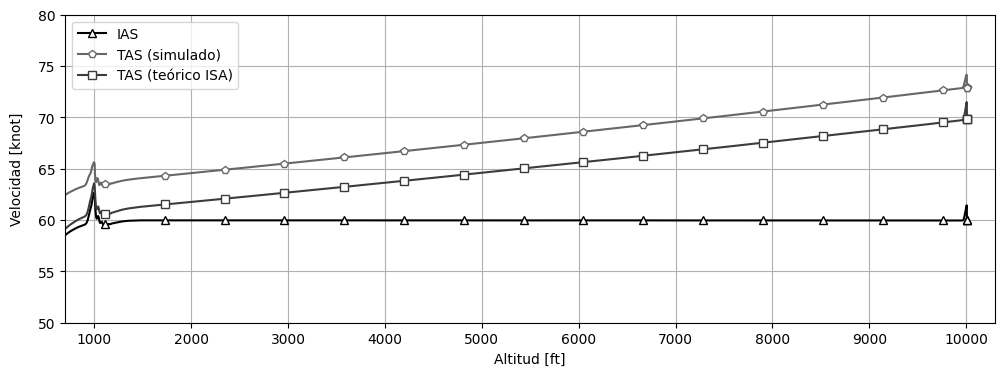

In [39]:
v_true_teo = [v_indicated[i]*np.sqrt(rho0/rho_Z[i]) for i in range(len(v_indicated))]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot( altitude_1,v_indicated, label='IAS', color='black', marker='^', markeredgecolor='black', markerfacecolor='white', markevery=95)
plt.plot(altitude_1,v_true_1, label='TAS (simulado)',color = '#676767', marker='p', markeredgecolor='#676767', markerfacecolor='white', markevery=95)
plt.plot(altitude_1,v_true_teo, label='TAS (teórico ISA)',color = "#3C3C3C", marker='s', markeredgecolor='#3C3C3C', markerfacecolor='white', markevery=95)
plt.xlabel('Altitud [ft]')
plt.ylabel('Velocidad [kn]')
plt.xticks(range(0, 10001, 1000))
plt.xlim(700, 10300)
plt.ylim(50,80)
plt.xlabel('Altitud [ft]')
plt.ylabel('Velocidad [knot]', labelpad=10)
plt.grid()
plt.legend()
plt.show()

#### Actividad 2
##### 2558 lb a 1000 ft

In [40]:
with open('cessna172-100kn-1000ft.csv', 'r') as archivo:
    lineas = [line.rstrip() for line in archivo]

v_true_2_1 = []      # [knot]
lift_2_1 = []        # [N]
drag_2_1 = []        # [N]
alpha_2_1 = []       # [°]

for i in lineas[1:-1]:
    v_true_2_1.append(float(i.split(',')[2]))
    lift_2_1.append((float(i.split(',')[20])+float(i.split(',')[21])+float(i.split(',')[22])+float(i.split(',')[23])+float(i.split(',')[24])+float(i.split(',')[25]))*4.45)
    drag_2_1.append((float(i.split(',')[26])+float(i.split(',')[27])+float(i.split(',')[28])+float(i.split(',')[29])+float(i.split(',')[30])+float(i.split(',')[31]))*4.45)
    alpha_2_1.append(float(i.split(',')[7]))

In [41]:
def cL(sust, altura, v_true):
    c_L = []
    if altura==1000: rho = 1.18955 # kg/m3
    else:            rho = 0.90464 # kg/m3
    for i in range(len(sust)):
        c_L.append(2 * sust[i] / (rho * 188*(0.3048**2) * (v_true[i]*0.514)**2))
    return c_L

def cD(arr, altura, v_true):
    c_D = []
    if altura==1000: rho = 1.18955 # kg/m3
    else:            rho = 0.90464 # kg/m3
    for i in range(len(arr)):
        c_D.append(2 * arr[i] / (rho * 188*(0.3048**2) * (v_true[i]*0.514)**2))
    return c_D

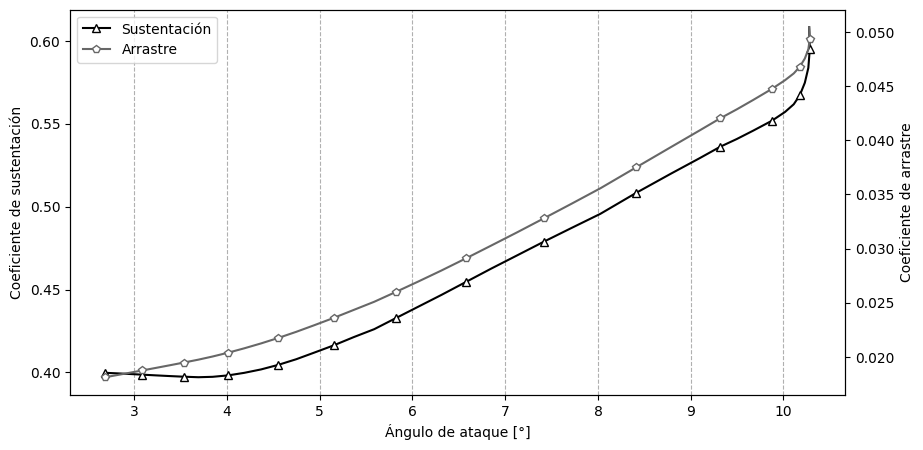

In [42]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1) = plt.subplots(1,1)

plotcl_2_1, = ax1.plot(alpha_2_1[28:-12], cL(lift_2_1[28:-12], 1000, v_true_2_1), color='black', marker='^', markeredgecolor='black', markerfacecolor='white', markevery=3)
ax1.set_xlabel('Ángulo de ataque [°]')
ax1.set_ylabel('Coeficiente de sustentación')

ax2 = ax1.twinx()

plotcd_2_1, = ax2.plot(alpha_2_1[28:-12], cD(drag_2_1[28:-12], 1000, v_true_2_1), color = '#676767', marker='p', markeredgecolor='#676767', markerfacecolor='white', markevery=3)
ax2.set_ylabel('Coeficiente de arrastre')

ax1.grid(linestyle='--', axis='x')
plt.legend([plotcl_2_1, plotcd_2_1], ['Sustentación', 'Arrastre'], loc='upper left')

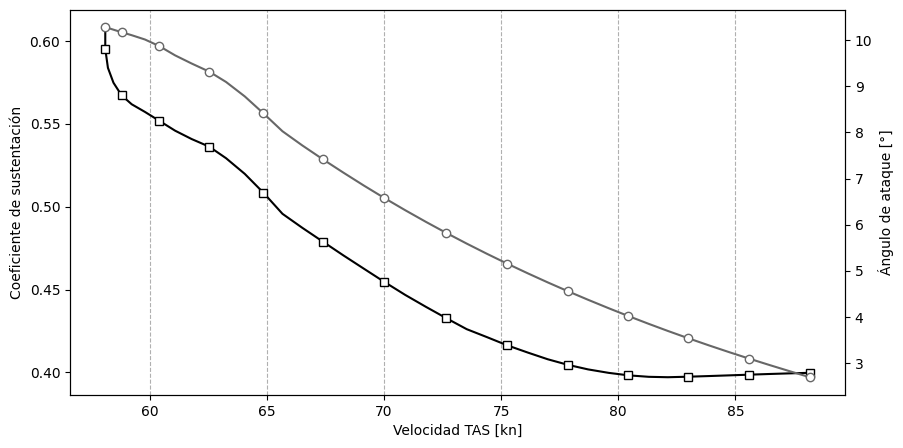

In [43]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1) = plt.subplots(1,1)

ax1.plot(v_true_2_1[28:-12], cL(lift_2_1[28:-12], 1000, v_true_2_1), color='black', marker='s', markeredgecolor='black', markerfacecolor='white', markevery=3)
ax1.set_xlabel('Velocidad TAS [kn]')
ax1.set_ylabel('Coeficiente de sustentación')

ax2 = ax1.twinx()

ax2.plot(v_true_2_1[28:-12], alpha_2_1[28:-12], color="#676767", marker='o', markeredgecolor='#676767', markerfacecolor='white', markevery=3)
ax2.set_xlabel('Velocidad TAS [kn]')
ax2.set_ylabel('Ángulo de ataque [°]')

ax1.grid(linestyle='--', axis='x')

##### 2558lb a 1000ft 2

In [59]:
with open('1000ft_2558lb.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_true_2_1_2 = []      # [knot]
lift_2_1_2 = []        # [N]
lift_meassured_1_2 = []
drag_meassured_1_2 = []
drag_2_1_2 = []        # [N]
alpha_2_1_2 = []       # [°]
CL_1_2=[]
CD_1_2=[]
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_true_2_1_2.append(float(i.split(';')[9]))
    lift_meassured_1_2.append(float(i.split(';')[27])*4.45)
    drag_meassured_1_2.append(float(i.split(';')[28])*4.45)
    lift_2_1_2.append((float(i.split(';')[37])+float(i.split(';')[38])+float(i.split(';')[39])+float(i.split(';')[40])+float(i.split(';')[41])+float(i.split(';')[42]))*4.45)
    drag_2_1_2.append((float(i.split(';')[43])+float(i.split(';')[44])+float(i.split(';')[45])+float(i.split(';')[46])+float(i.split(';')[47])+float(i.split(';')[48]))*4.45)
    CL_1_2.append(float(i.split(';')[34]))
    CD_1_2.append(float(i.split(';')[35]))
    alpha_2_1_2.append(float(i.split(';')[14]))



cl_1_2=cL(lift_2_1_2, 1000, v_true_2_1_2)
cl_m_1_2=cL(lift_meassured_1_2, 1000, v_true_2_1_2)
cd_1_2=cD(drag_2_1_2, 1000, v_true_2_1_2)
cd_m_1_2=cD(drag_meassured_1_2,1000, v_true_2_1_2)

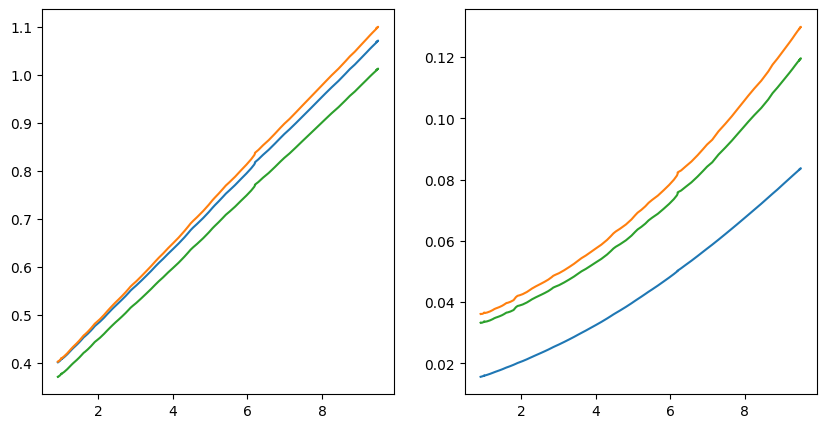

In [60]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(alpha_2_1_2[60:-10], cl_1_2[60:-10])
ax1.plot(alpha_2_1_2[60:-10], cl_m_1_2[60:-10])
ax1.plot(alpha_2_1_2[60:-10], CL_1_2[60:-10])
ax2.plot(alpha_2_1_2[60:-10], cd_1_2[60:-10])
ax2.plot(alpha_2_1_2[60:-10], cd_m_1_2[60:-10])
ax2.plot(alpha_2_1_2[60:-10], CD_1_2[60:-10])

##### 1730 lb a 1000 ft

In [61]:
with open('1000ft_1730lb_3.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_true_2_2 = []      # [knot]
lift_2_2 = []        # [N]
lift_meassured_2 = []
drag_meassured_2 = []
drag_2_2 = []        # [N]
alpha_2_2 = []       # [°]
CL_2=[]
CD_2=[]
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_true_2_2.append(float(i.split(';')[9]))
    lift_meassured_2.append(float(i.split(';')[27])*4.45)
    drag_meassured_2.append(float(i.split(';')[28])*4.45)
    lift_2_2.append((float(i.split(';')[37])+float(i.split(';')[38])+float(i.split(';')[39])+float(i.split(';')[40])+float(i.split(';')[41])+float(i.split(';')[42]))*4.45)
    drag_2_2.append((float(i.split(';')[43])+float(i.split(';')[44])+float(i.split(';')[45])+float(i.split(';')[46])+float(i.split(';')[47])+float(i.split(';')[48]))*4.45)
    CL_2.append(float(i.split(';')[34]))
    CD_2.append(float(i.split(';')[35]))
    alpha_2_2.append(float(i.split(';')[14]))



cl_2=cL(lift_2_2, 1000, v_true_2_2)
cl_m_2=cL(lift_meassured_2, 1000, v_true_2_2)
cd_2=cD(drag_2_2, 1000, v_true_2_2)
cd_m_2=cD(drag_meassured_2,1000, v_true_2_2)
# print(cl)

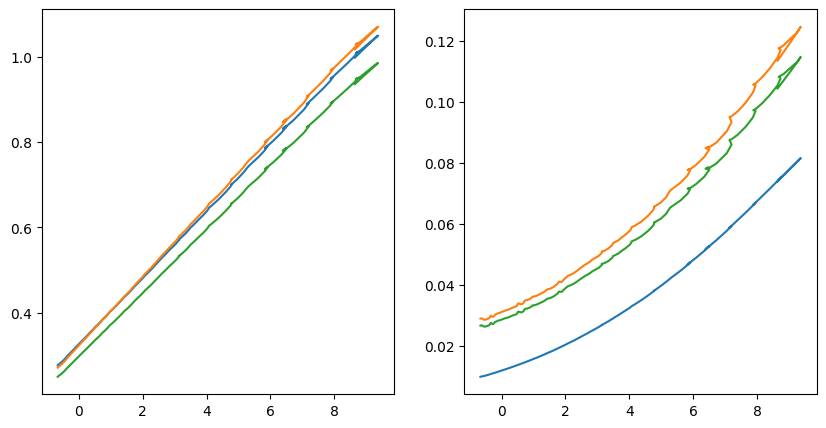

In [62]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(alpha_2_2[60:-15], cl_2[60:-15])
ax1.plot(alpha_2_2[60:-15], cl_m_2[60:-15])
ax1.plot(alpha_2_2[60:-15], CL_2[60:-15])
ax2.plot(alpha_2_2[60:-15], cd_2[60:-15])
ax2.plot(alpha_2_2[60:-15], cd_m_2[60:-15])
ax2.plot(alpha_2_2[60:-15], CD_2[60:-15])

##### 2558 lb a 10000 ft

In [73]:
with open('10000ft_2558lb_3.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_true_2_3 = []      # [knot]
lift_2_3 = []        # [N]
drag_2_3 = []        # [N]
alpha_2_3 = []       # [°]
CL_3=[]
CD_3=[]

# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_true_2_3.append(float(i.split(';')[9]))
    lift_2_3.append((float(i.split(';')[31])+float(i.split(';')[32])+float(i.split(';')[33])+float(i.split(';')[34])+float(i.split(';')[35])+float(i.split(';')[36]))*4.45)
    # lift_2_3.append(float(i.split(';')[23])*4.45)
    drag_2_3.append((float(i.split(';')[37])+float(i.split(';')[38])+float(i.split(';')[39])+float(i.split(';')[40])+float(i.split(';')[41])+float(i.split(';')[42]))*4.45)
    # drag_2_3.append(float(i.split(';')[29])*4.45)
    CL_3.append(float(i.split(';')[28]))
    CD_3.append(float(i.split(';')[29]))
    alpha_2_3.append(float(i.split(';')[14]))

cl_3=cL(lift_2_3, 1, v_true_2_3)
cd_3=cD(drag_2_3, 1, v_true_2_3)
# print(cl)

1.058162660960522
0.7008766676122201


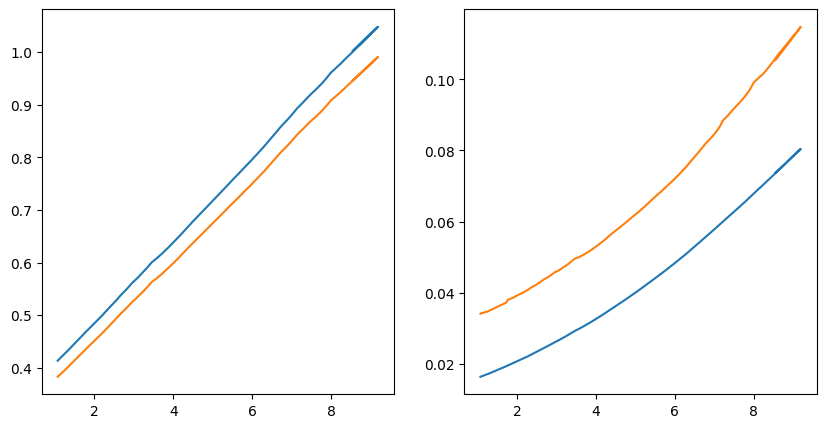

In [74]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(alpha_2_3[0:-9], cl_3[0:-9])
ax1.plot(alpha_2_3[0:-9], CL_3[0:-9])
ax2.plot(alpha_2_3[0:-9], cd_3[0:-9])
ax2.plot(alpha_2_3[0:-9], CD_3[0:-9])
print(cl_3[120]/CL_3[120])
print(cd_3[120]/CD_3[120])


##### 1730lb 10000ft

In [75]:
with open('10000ft_1730lb.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_true_2_4 = []      # [knot]
lift_2_4 = []        # [N]
lift_meassured_4 = []
drag_meassured_4 = []
drag_2_4 = []        # [N]
alpha_2_4 = []       # [°]
CL_4=[]
CD_4=[]
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_true_2_4.append(float(i.split(';')[9]))
    lift_meassured_4.append(float(i.split(';')[27])*4.45)
    drag_meassured_4.append(float(i.split(';')[28])*4.45)
    lift_2_4.append((float(i.split(';')[37])+float(i.split(';')[38])+float(i.split(';')[39])+float(i.split(';')[40])+float(i.split(';')[41])+float(i.split(';')[42]))*4.45)
    drag_2_4.append((float(i.split(';')[43])+float(i.split(';')[44])+float(i.split(';')[45])+float(i.split(';')[46])+float(i.split(';')[47])+float(i.split(';')[48]))*4.45)
    CL_4.append(float(i.split(';')[34]))
    CD_4.append(float(i.split(';')[35]))
    alpha_2_4.append(float(i.split(';')[14]))



cl_4=cL(lift_2_4, 1, v_true_2_4)
cl_m_4=cL(lift_meassured_4, 1, v_true_2_4)
cd_4=cD(drag_2_4, 1, v_true_2_4)
cd_m_4=cD(drag_meassured_4,1, v_true_2_4)

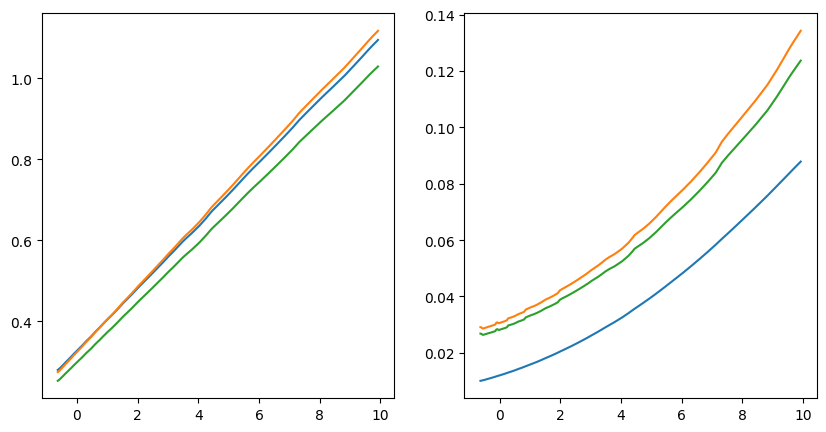

In [76]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(alpha_2_4[2:-10], cl_4[2:-10])
ax1.plot(alpha_2_4[2:-10], cl_m_4[2:-10])
ax1.plot(alpha_2_4[2:-10], CL_4[2:-10])
ax2.plot(alpha_2_4[2:-10], cd_4[2:-10])
ax2.plot(alpha_2_4[2:-10], cd_m_4[2:-10])
ax2.plot(alpha_2_4[2:-10], CD_4[2:-10])

### Gráficos

#### Actividad 2

##### Polares

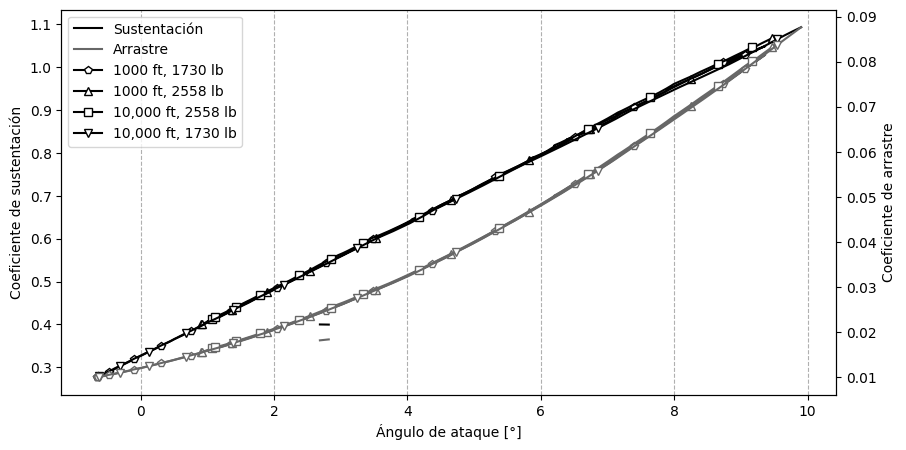

In [80]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1) = plt.subplots(1,1)

ax1.set_xlabel('Ángulo de ataque [°]')
ax1.set_ylabel('Coeficiente de sustentación')

líneanegra, = ax1.plot(alpha_2_1[28:30], cL(lift_2_1[28:30], 1000, v_true_2_1), color='black')
plotcl_2_1, = ax1.plot(alpha_2_1_2[60:-11], cl_1_2[60:-11], color='black', marker='^', markeredgecolor='black', markerfacecolor='white', markevery=10)
plotcl_2_2, = ax1.plot(alpha_2_2[60:-15], cl_2[60:-15], color= 'black', marker='p', markeredgecolor='black', markerfacecolor='white', markevery=10)
plotcl_2_3, = ax1.plot(alpha_2_3[0:121], cl_3[0:121], color= 'black', marker='s', markeredgecolor='black', markerfacecolor='white', markevery=10)
plotcl_2_4, = ax1.plot(alpha_2_4[2:-11], cl_4[2:-11], color='black', marker='v', markeredgecolor='black', markerfacecolor='white', markevery=10)

ax2 = ax1.twinx()
ax2.set_ylabel('Coeficiente de arrastre')

líneasix7,  = ax2.plot(alpha_2_1[28:30], cD(drag_2_1[28:30], 1000, v_true_2_1), color='#676767')
plotcd_2_1, = ax2.plot(alpha_2_1_2[60:-11], cd_1_2[60:-11], color = '#676767', marker='^', markeredgecolor='#676767', markerfacecolor='white', markevery=10)
plotcd_2_2, = ax2.plot(alpha_2_2[60:-15], cd_2[60:-15], color= '#676767', marker='p', markeredgecolor='#676767', markerfacecolor='white', markevery=10)
plotcd_2_3, = ax2.plot(alpha_2_3[0:121], cd_3[0:121], color= '#676767', marker='s', markeredgecolor='#676767', markerfacecolor='white', markevery=10)
plotcd_2_4, = ax2.plot(alpha_2_4[2:-11], cd_4[2:-11], color= '#676767', marker='v', markeredgecolor= '#676767', markerfacecolor='white', markevery=10)

ax1.grid(linestyle='--', axis='x')
plt.legend([líneanegra, líneasix7, plotcl_2_2, plotcl_2_1, plotcl_2_3, plotcl_2_4], ['Sustentación', 'Arrastre', '1000 ft, 1730 lb', '1000 ft, 2558 lb', '10,000 ft, 2558 lb', '10,000 ft, 1730 lb'], loc='upper left')